<h1 style="color:rgb(199, 12, 77);">Bitcoin Historical Data - Exploratory Data Analysis</h1>

<h2 style="color:rgb(247, 147, 26)">Notebook Objective</h2> 

Exploring Bitcoin market patterns, trends, volume behavior, and statistical relationships between variables.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [9]:
df = pd.read_csv(
    "../data/processed/bitcoin_processed.csv",
    parse_dates=["Date"]
)

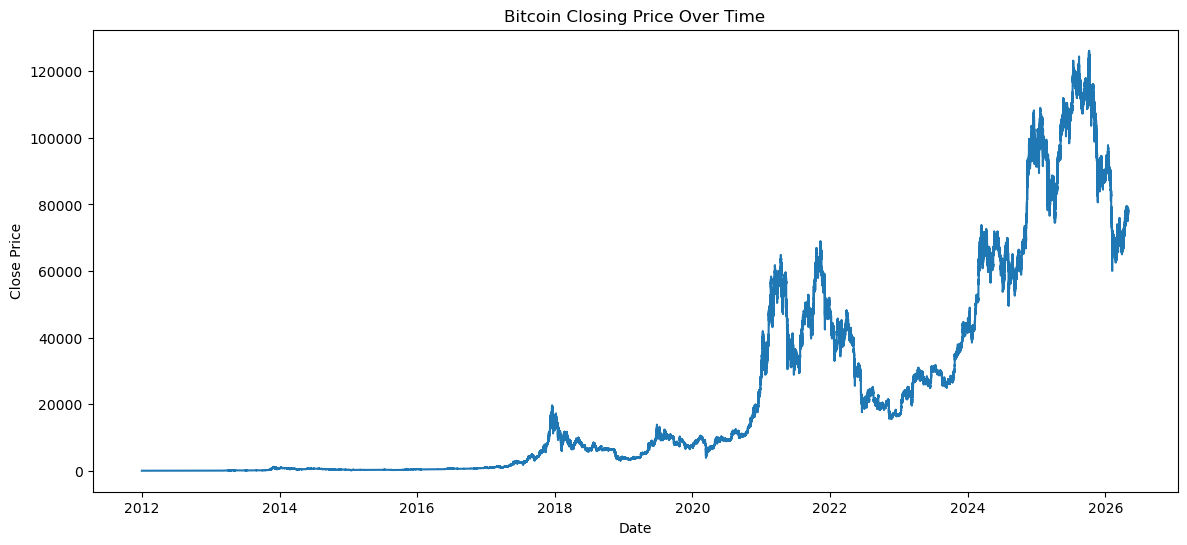

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.savefig("../outputs/figures/notebook1_figures/bitcoin_price_trend.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Bitcoin Price Trend</h3>

> The closing price of Bitcoin shows a strong long-term upward trend, especially in the later years of the dataset.

> This is important because it shows that Bitcoin price behavior is highly non-linear and changes significantly over time. The market does not follow a stable or smooth pattern.

> From a market perspective, this indicates that Bitcoin has experienced multiple growth cycles, sharp corrections, and high volatility periods, which makes price prediction more challenging.

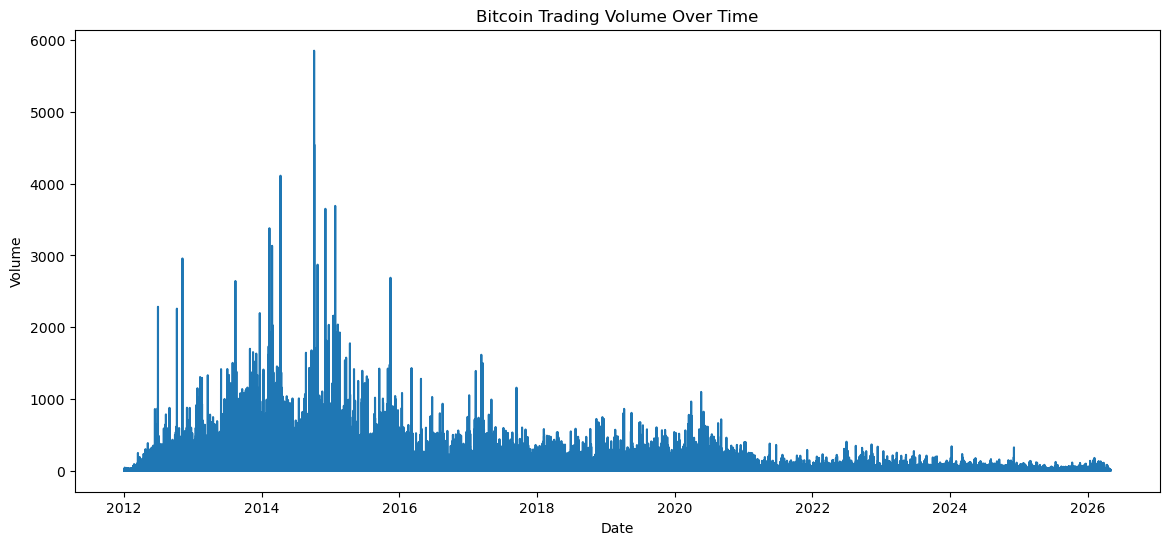

In [14]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Volume"])
plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.savefig("../outputs/figures/notebook1_figures/Bitcoin Trading Volume Over Time.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Bitcoin Trading Volume Over Time</h3>

> The trading volume changes significantly over time and includes several sharp spikes.

> This is important because trading volume represents market activity and investor participation. Higher volume often indicates stronger interest, increased liquidity, or reactions to important market events.

> The market behavior suggests that Bitcoin trading activity is not constant and may increase during periods of uncertainty, speculation, or strong price movement.

In [13]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00


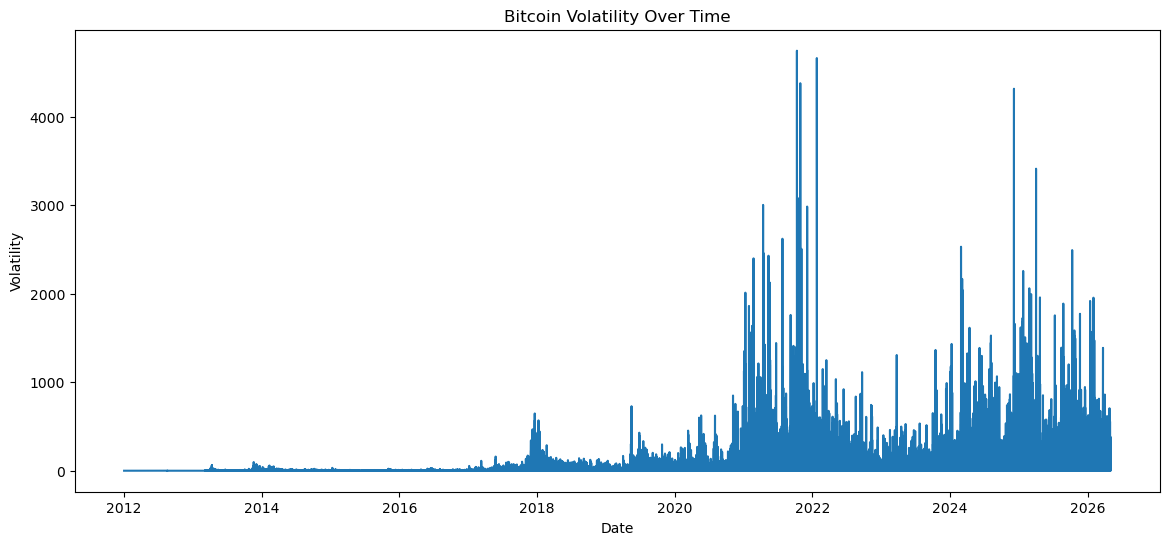

In [153]:
df["Volatility"] = df["High"] - df["Low"]

plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Volatility"])
plt.title("Bitcoin Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.savefig("../outputs/figures/notebook2_figures/Bitcoin Volatility Over Time.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Bitcoin Volatility Over Time</h3>

> Volatility varies strongly across the dataset, with some periods showing much larger price ranges than others.

> This is important because volatility measures how unstable or risky the market is during a given time period. High volatility means that prices are changing rapidly.

> The market behavior suggests that Bitcoin does not maintain a constant risk level over time. Instead, it moves through calm and highly unstable periods.

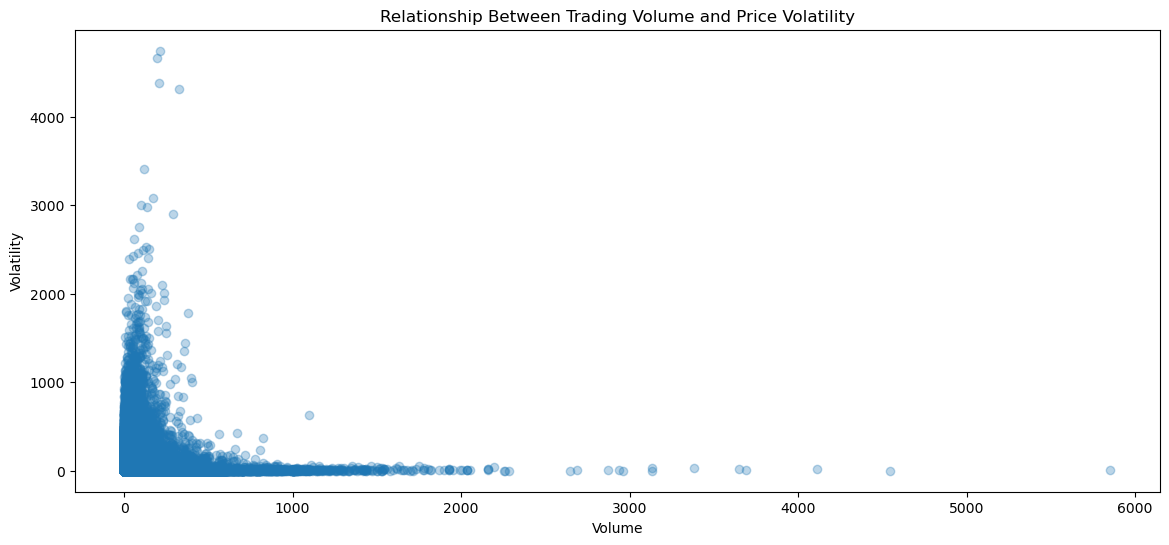

In [154]:
plt.figure(figsize=(14,6))

plt.scatter(df["Volume"],df["Volatility"], alpha=0.3)

plt.title("Relationship Between Trading Volume and Price Volatility")
plt.xlabel("Volume")
plt.ylabel("Volatility")
plt.savefig("../outputs/figures/notebook2_figures/Relationship Between Trading Volume and Price Volatility.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Volume and Volatility Relationship</h3>

> This scatter plot shows the relationship between trading volume and price volatility.

> Most observations are concentrated in lower-volume and lower-volatility regions, while extreme volatility values appear less frequently.

> This is important because it shows that high volatility is not always directly explained by high trading volume. Market instability may also be caused by sudden events, liquidity changes, or rapid shifts in investor sentiment.

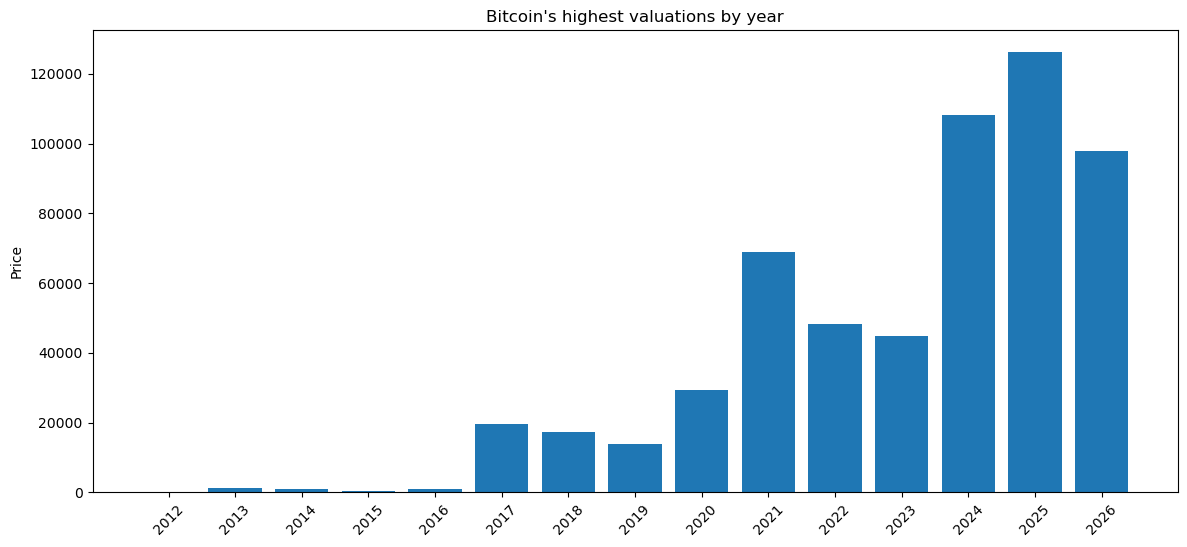

In [156]:
df["Year"] = df["Date"].dt.year

max_values = df.groupby("Year")["Close"].max()
 
plt.figure(figsize=(14,6))

plt.bar(max_values.index,max_values.values)

plt.xticks(max_values.index, rotation=45)

plt.ylabel("Price")

plt.title("Bitcoin's highest valuations by year")
plt.savefig("../outputs/figures/notebook2_figures/Bitcoin's highest valuations by year.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Highest Bitcoin Valuation by Year</h3>

> This bar chart shows the maximum Bitcoin closing price observed in each year.

> The chart clearly shows that Bitcoin reached much higher price levels in recent years compared to the early years of the dataset.

> This is important because it highlights Bitcoin's long-term growth and market expansion. The market behavior indicates that Bitcoin has gone through major valuation cycles, with some years reaching significantly higher peaks than others.

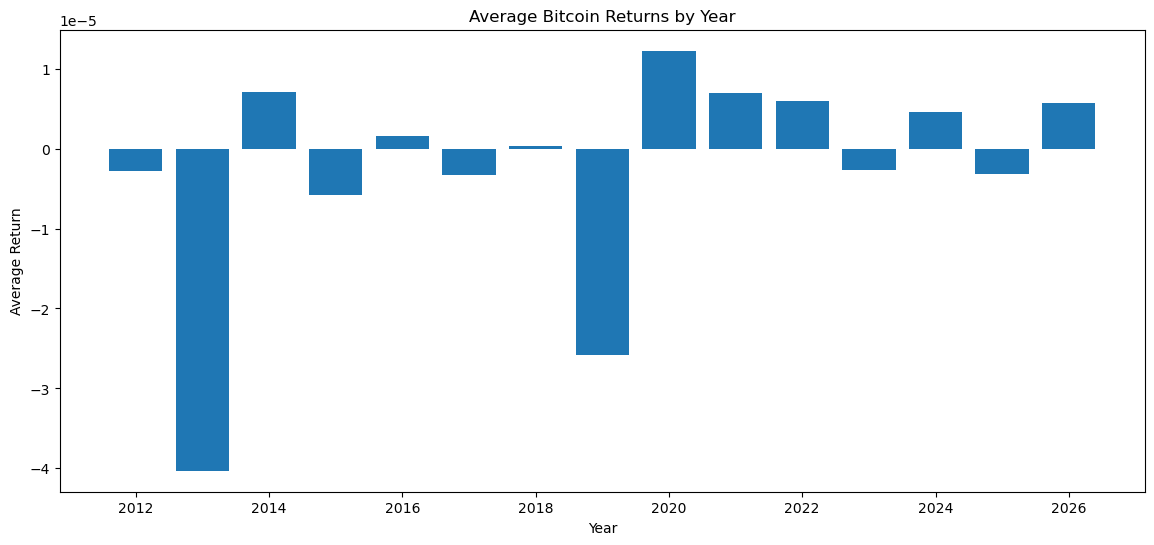

In [157]:
df["Return"] = (df["Close"] - df["Open"])/df["Open"]

yearly_returns = df.groupby("Year")["Return"].mean()

plt.figure(figsize=(14,6))

plt.bar(yearly_returns.index, yearly_returns.values)

plt.title("Average Bitcoin Returns by Year")
plt.xlabel("Year")
plt.ylabel("Average Return")
plt.savefig("../outputs/figures/notebook2_figures/Average Bitcoin Returns by Year.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Average Bitcoin Returns by Year</h3>

> This chart shows the average return for each year.

> The average yearly return values are relatively small compared to the large price changes observed in the market. This happens because positive and negative short-term returns often balance each other out.

> This is important because it shows that average return alone may not fully explain Bitcoin market behavior. For financial time-series data, volatility and return distribution are often more informative than simple average returns.

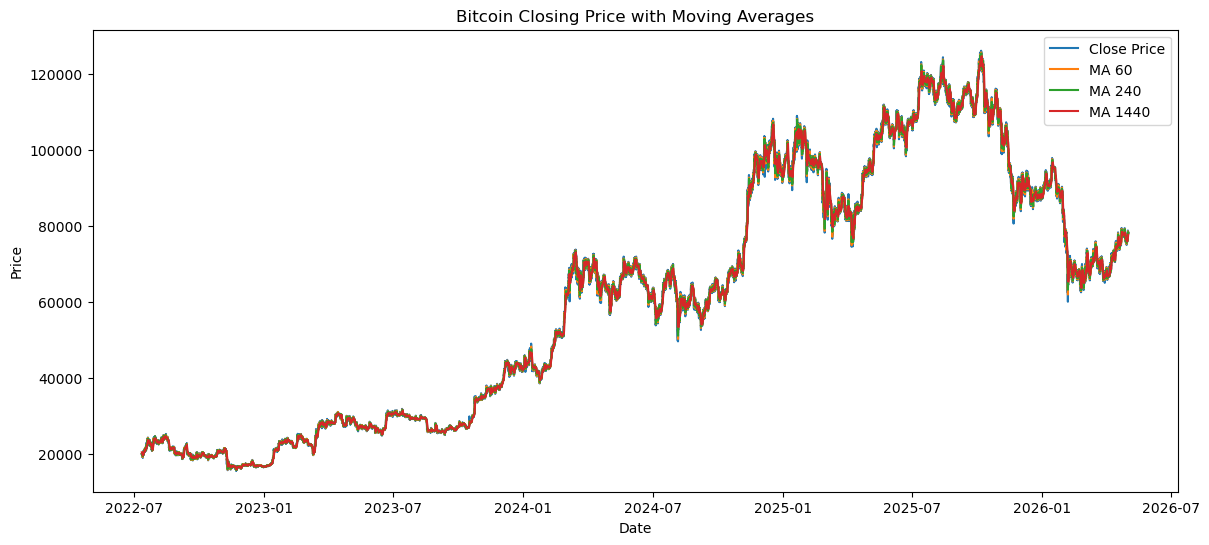

In [158]:
df["MA_60"] = df["Close"].rolling(window=60).mean()
df["MA_240"] = df["Close"].rolling(window=240).mean()
df["MA_1440"] = df["Close"].rolling(window=1440).mean()

sample_df = df.tail(2000000)

plt.figure(figsize=(14,6))

plt.plot(sample_df["Date"], sample_df["Close"], label="Close Price")
plt.plot(sample_df["Date"], sample_df["MA_60"], label="MA 60")
plt.plot(sample_df["Date"], sample_df["MA_240"], label="MA 240")
plt.plot(sample_df["Date"], sample_df["MA_1440"], label="MA 1440")

plt.title("Bitcoin Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.savefig("../outputs/figures/notebook2_figures/Bitcoin Closing Price with Moving Averages.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Moving Average and Trend Analysis</h3>

> This chart compares the Bitcoin closing price with multiple moving averages: MA 60, MA 240, and MA 1440.

> Moving averages help smooth short-term noise and reveal the underlying market trend more clearly. Shorter moving averages react faster to price changes, while longer moving averages provide a more stable view of the overall trend.

> This is important because Bitcoin prices are highly volatile. Moving averages make it easier to observe trend direction, momentum changes, and possible trend reversals.

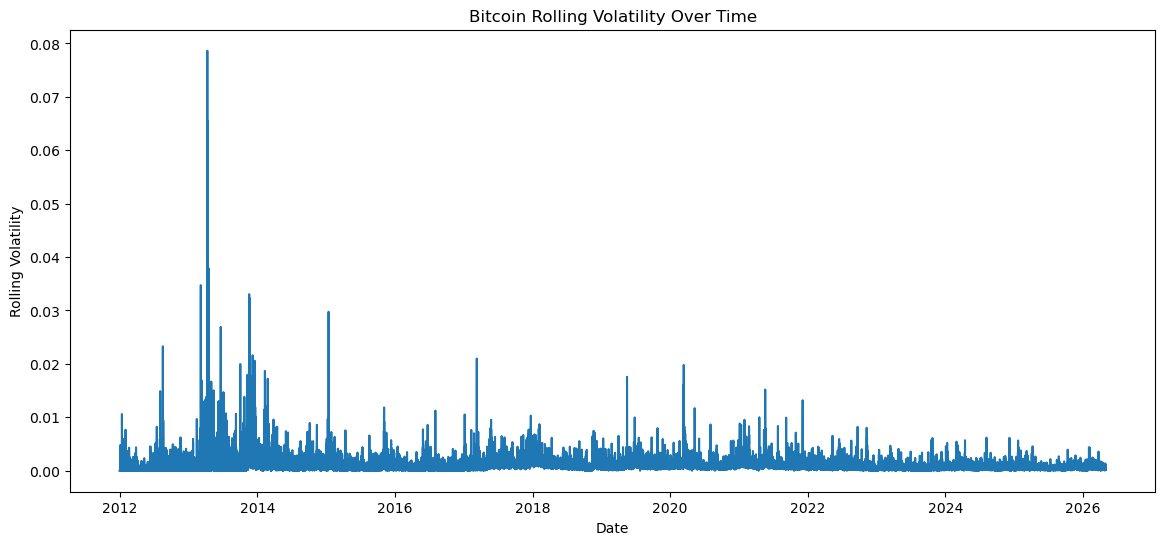

In [159]:
df["Rolling_Volatility"] = df["Return"].rolling(window=60).std()

plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Rolling_Volatility"])

plt.title("Bitcoin Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.savefig("../outputs/figures/notebook2_figures/Bitcoin Rolling Volatility Over Time.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Rolling Volatility Analysis</h3>

> Rolling volatility shows how Bitcoin market instability changes over time.

> The chart indicates that volatility is not constant. Some periods show clear spikes, meaning that the market experienced stronger price fluctuations during those intervals.

> This is important because volatility clustering is common in financial markets. High-volatility periods may be followed by continued instability, which is highly relevant for risk analysis and regression modeling.

In [102]:
correlation_matrix = df[["Open","High","Low","Close","Volume","Volatility","Price_change","Rolling_Volatility"]].corr()

correlation_matrix

,Open,High,Low,Close,Volume,Volatility,Price_change,Rolling_Volatility
Open,1.000000,1.000000,1.000000,1.000000,-0.095696,0.479363,0.000435,-0.172217
High,1.000000,1.000000,1.000000,1.000000,-0.095639,0.479785,0.000891,-0.172113
Low,1.000000,1.000000,1.000000,1.000000,-0.095762,0.478911,0.000901,-0.172324
Close,1.000000,1.000000,1.000000,1.000000,-0.095701,0.479354,0.001315,-0.172216
Volume,-0.095696,-0.095639,-0.095762,-0.095701,1.000000,0.062649,-0.005806,0.239716
Volatility,0.479363,0.479785,0.478911,0.479354,0.062649,1.000000,-0.009139,0.102980
Price_change,0.000435,0.000891,0.000901,0.001315,-0.005806,-0.009139,1.000000,0.000723
Rolling_Volatility,-0.172217,-0.172113,-0.172324,-0.172216,0.239716,0.102980,0.000723,1.000000


In [160]:
df.tail()

,Timestamp,Open,High,Low,Close,Volume,Date,Volatility,Year,Price_change,Return,MA_60,MA_240,MA_1440,Rolling_Volatility,Month,Hour,Range,Cumulative_Return
7536647,1.777680e+09,78250.0,78250.0,78244.0,78245.0,0.233410,2026-05-02 00:08:00,6.0,2026,-5.0,-0.000064,78138.983333,78138.854167,77648.502083,0.000188,May,0,6.0,5.668308e-14
7536648,1.777681e+09,78245.0,78254.0,78238.0,78254.0,0.792507,2026-05-02 00:09:00,16.0,2026,9.0,0.000115,78141.183333,78138.587500,77649.738194,0.000178,May,0,16.0,5.668960e-14
7536649,1.777681e+09,78257.0,78257.0,78250.0,78256.0,0.101332,2026-05-02 00:10:00,7.0,2026,-1.0,-0.000013,78142.750000,78138.375000,77650.988194,0.000166,May,0,7.0,5.668888e-14
7536650,1.777681e+09,78254.0,78254.0,78251.0,78251.0,0.208058,2026-05-02 00:11:00,3.0,2026,-3.0,-0.000038,78144.216667,78138.154167,77652.230556,0.000166,May,0,3.0,5.668671e-14
7536651,1.777681e+09,78243.0,78244.0,78220.0,78220.0,0.207017,2026-05-02 00:12:00,24.0,2026,-23.0,-0.000294,78145.233333,78137.791667,77653.456250,0.000170,May,0,24.0,5.667004e-14


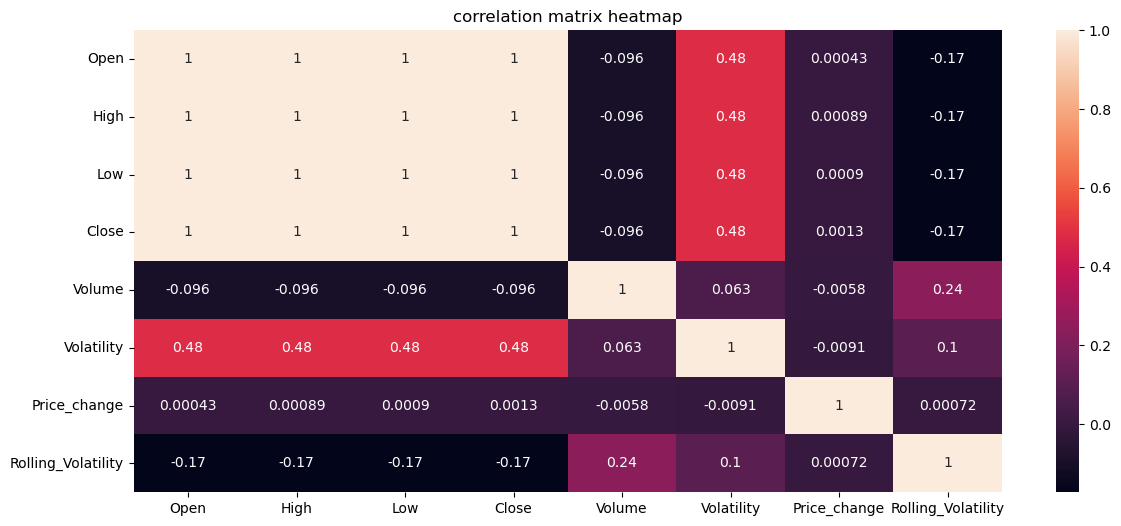

In [161]:
plt.figure(figsize=(14,6))
sns.heatmap(correlation_matrix,annot=True)
plt.title("correlation matrix heatmap")
plt.savefig("../outputs/figures/notebook2_figures/correlation matrix heatmap.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Correlation Matrix Analysis</h3>

> The correlation heatmap shows very strong relationships between Open, High, Low, and Close prices.

> This is expected because these OHLC variables are measured within the same time interval and tend to move together.

> This is important for machine learning because highly correlated features may contain redundant information. During modeling, feature selection or regularized models may help reduce the effect of multicollinearity.

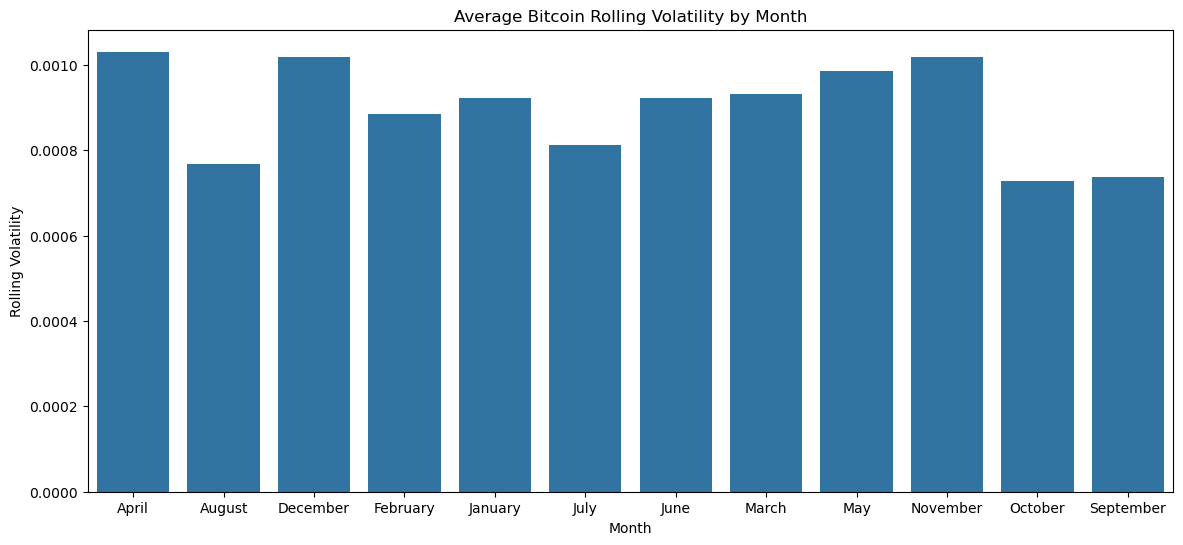

In [162]:
df["Month"] = df["Date"].dt.month_name()

monthly_change = df.groupby("Month")["Rolling_Volatility"].mean()

plt.figure(figsize=(14,6))
sns.barplot(x=monthly_change.index,y=monthly_change.values)
plt.title("Average Bitcoin Rolling Volatility by Month")
plt.xlabel("Month")
plt.ylabel("Rolling Volatility")
plt.savefig("../outputs/figures/notebook2_figures/Average Bitcoin Rolling Volatility by Month.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Monthly Rolling Volatility Analysis</h3>

> This chart shows the average rolling volatility for each month.

> The differences between months are not extremely large, which suggests that Bitcoin volatility does not follow a strong monthly seasonal pattern.

> This is important because it indicates that volatility is likely driven more by market events, news, investor sentiment, and liquidity conditions rather than by calendar months.

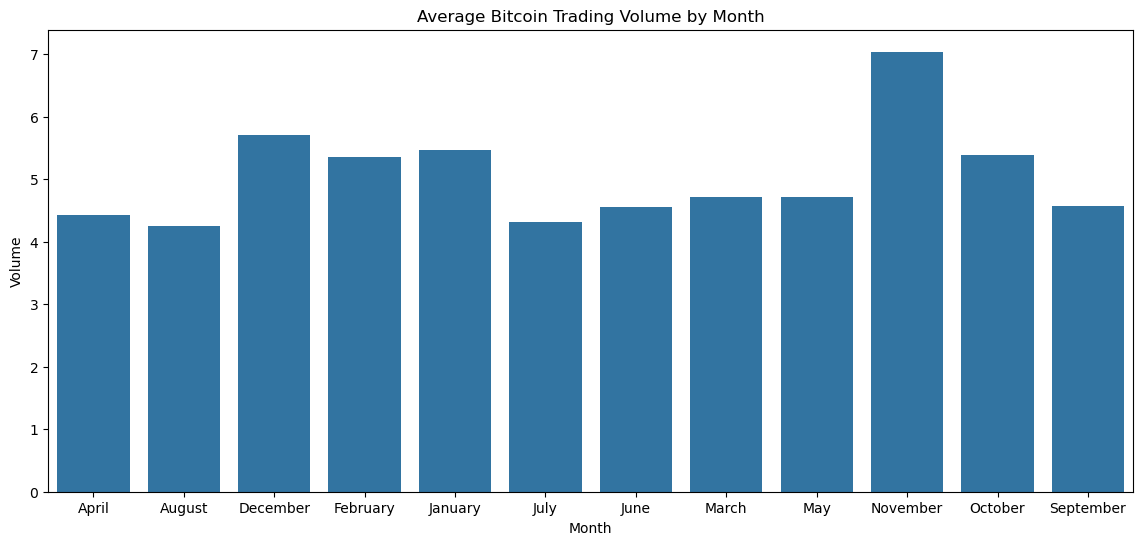

In [163]:
monthly_change = df.groupby("Month")["Volume"].mean()

plt.figure(figsize=(14,6))
sns.barplot(x=monthly_change.index,y=monthly_change.values)
plt.title("Average Bitcoin Trading Volume by Month")
plt.xlabel("Month")
plt.ylabel("Volume")
plt.savefig("../outputs/figures/notebook2_figures/Average Bitcoin Trading Volume by Month.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Monthly Trading Volume Analysis</h3>

> This chart shows the average Bitcoin trading volume across different months.

> The volume varies moderately by month, but there is no clear and strong monthly seasonal pattern.

> This is important because market activity appears to be influenced more by external market conditions than by the month itself. Trading volume may increase during important events, strong price moves, or periods of high investor attention.

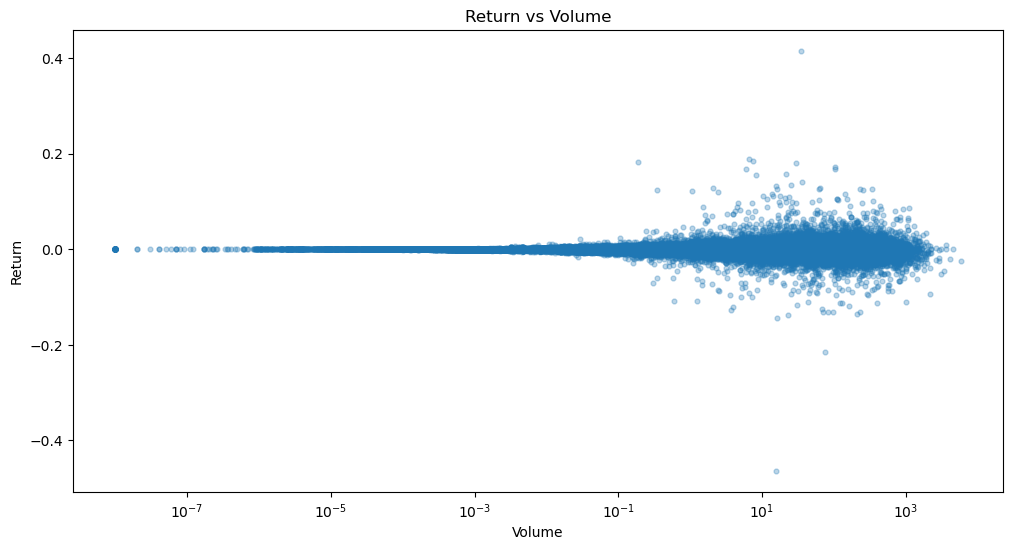

In [165]:
plt.figure(figsize=(12,6))

plt.scatter(
    df["Volume"],
    df["Return"],
    alpha=0.3,
    s=12
)

plt.xscale("log")

plt.title("Return vs Volume")
plt.xlabel("Volume")
plt.ylabel("Return")

plt.savefig("../outputs/figures/notebook2_figures/Return vs Volume.png",dpi=300,
    bbox_inches="tight")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Return and Volume Relationship</h3>

> This scatter plot examines the relationship between trading volume and return.

> The chart suggests that most returns are concentrated around zero, even across different volume levels. This means that high trading volume does not always produce large positive or negative returns.

> This is important because it shows that volume alone may not be sufficient to explain price direction. Other factors such as volatility, trend, market sentiment, and previous price behavior may also be important for prediction.

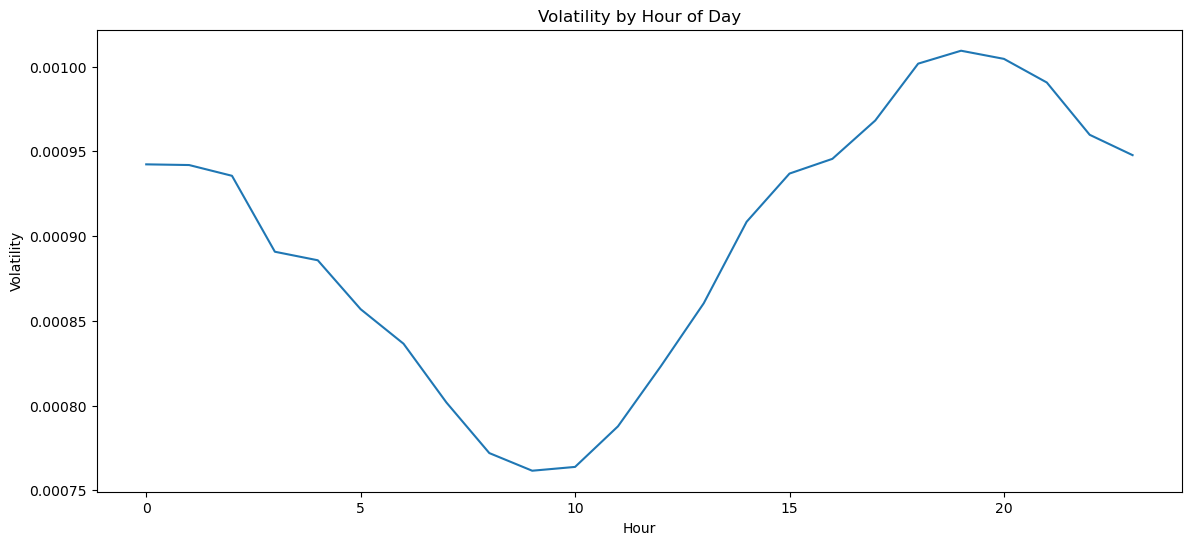

In [166]:
df["Hour"] = df["Date"].dt.hour

hourly_vol = df.groupby("Hour")["Rolling_Volatility"].mean()

plt.figure(figsize=(14,6))

plt.plot(hourly_vol.index, hourly_vol.values)

plt.title("Volatility by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Volatility")

plt.savefig("../outputs/figures/notebook2_figures/Volatility by Hour of Day.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Hourly Volatility Analysis</h3>

> This chart shows the average rolling volatility by hour of the day.

> The goal is to understand whether Bitcoin volatility changes depending on the time of day. Since Bitcoin trades 24/7, hourly patterns may reflect differences in global market activity.

> This is important because some hours may correspond to higher participation from major markets. If hourly volatility patterns exist, time-based features may be useful during model development.

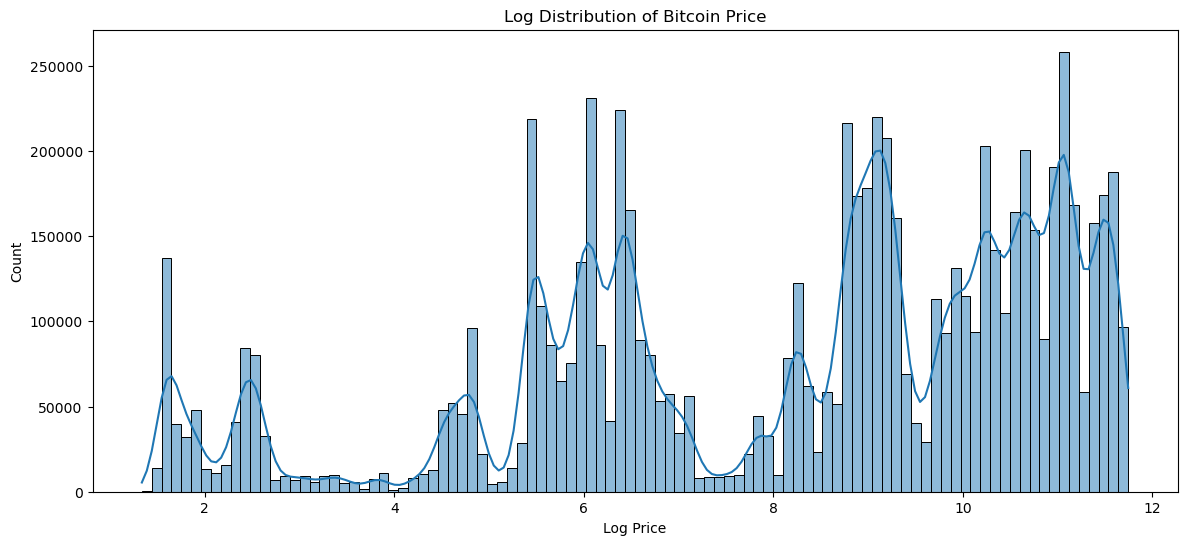

In [167]:
plt.figure(figsize=(14,6))

sns.histplot(np.log(df["Close"]), bins=100, kde=True)

plt.title("Log Distribution of Bitcoin Price")
plt.xlabel("Log Price")

plt.savefig("../outputs/figures/notebook2_figures/Log Distribution of Bitcoin Price.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Log Price Distribution</h3>

> The log-transformed Bitcoin price distribution appears more balanced compared to the original price distribution.

> This is important because the original Bitcoin price distribution is heavily right-skewed due to long-term exponential growth. Applying a log transformation helps reduce skewness and makes the distribution easier to analyze.

> From a modeling perspective, log transformation may improve regression performance by reducing the effect of extreme price values.

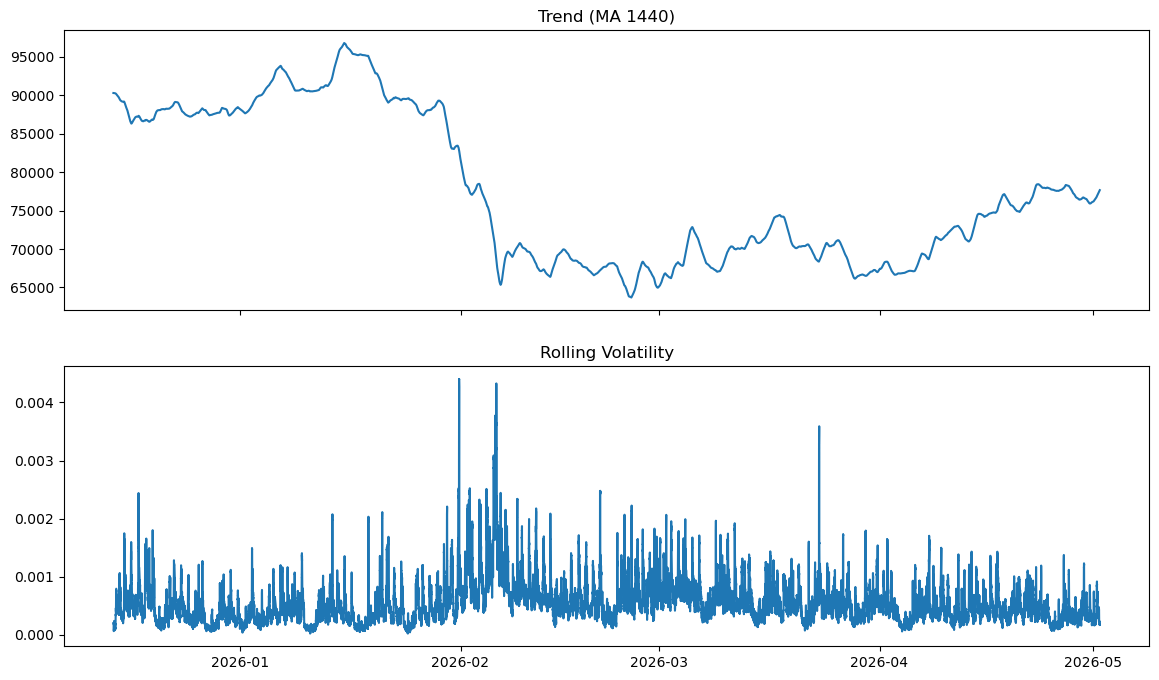

In [168]:
fig, ax = plt.subplots(2, 1, figsize=(14,8), sharex=True)

sample_df = df.tail(200000)

ax[0].plot(sample_df["Date"], sample_df["MA_1440"])
ax[0].set_title("Trend (MA 1440)")

ax[1].plot(sample_df["Date"], sample_df["Rolling_Volatility"])
ax[1].set_title("Rolling Volatility")

plt.savefig("../outputs/figures/notebook2_figures/Rolling Volatility_and_TrendPrice.png",dpi=300,
    bbox_inches="tight")

plt.show()

> <h3 style="color:rgb(247, 147, 26)">Trend and Rolling Volatility Comparison</h3>

> This visualization compares the long-term trend with rolling volatility in separate subplots.

> Separating the two plots makes the comparison easier because price and volatility are measured on very different scales. The trend plot shows the general direction of Bitcoin prices, while the volatility plot shows periods of market instability.

> This is important because price growth and volatility do not always move together. The market can rise during both stable and unstable periods, so volatility should be analyzed as a separate risk-related feature.

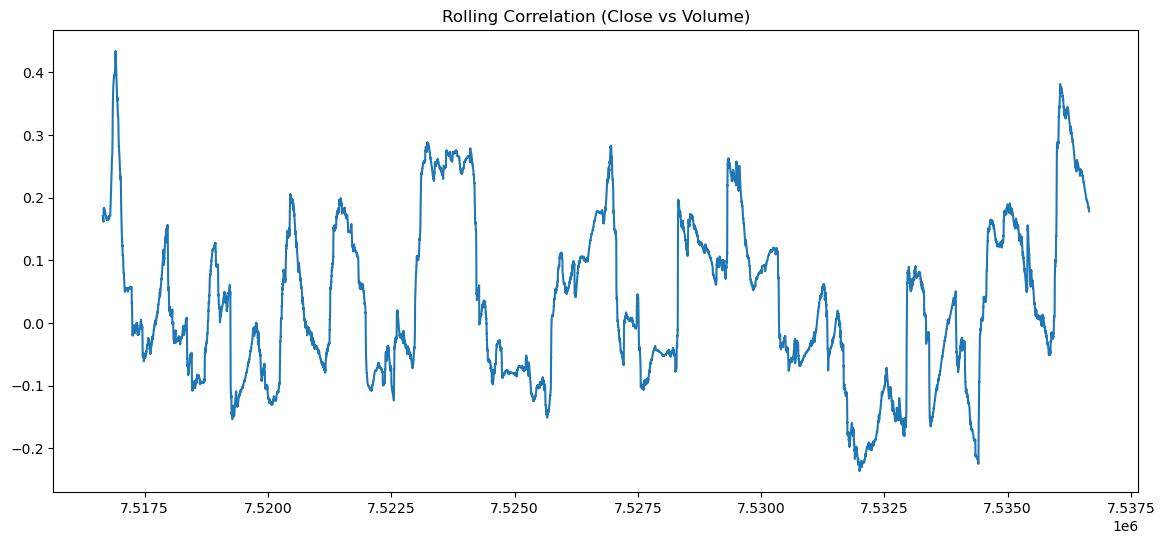

In [169]:
rolling_corr = df["Close"].rolling(1000).corr(df["Volume"])

sample = rolling_corr.tail(20000)

plt.figure(figsize=(14,6))
plt.plot(sample)

plt.title("Rolling Correlation (Close vs Volume)")
plt.savefig("../outputs/figures/notebook2_figures/Close vs Volume.png",dpi=300,
    bbox_inches="tight")
plt.show()

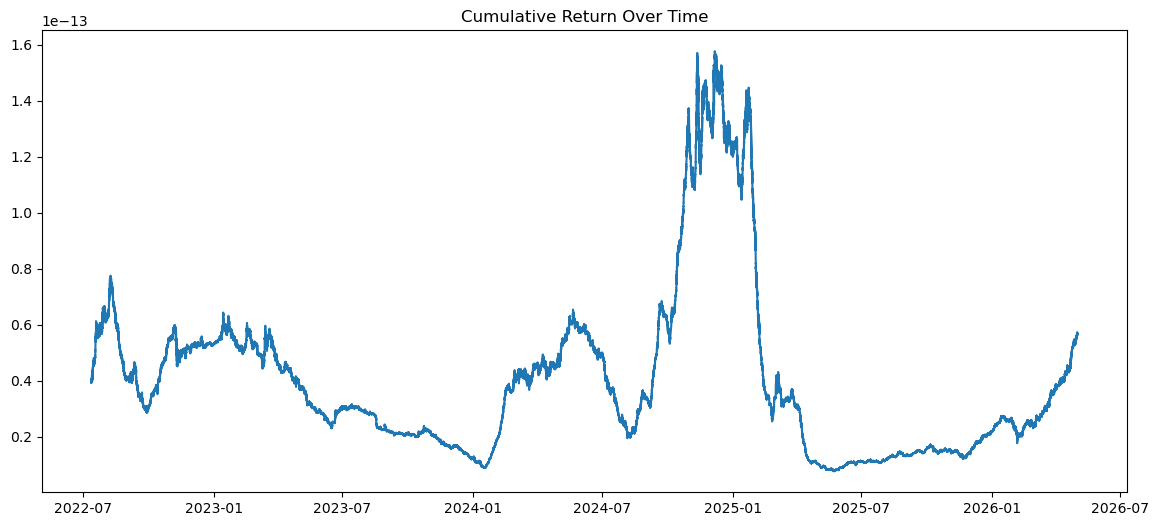

In [171]:
df["Cumulative_Return"] = (1 + df["Return"]).cumprod()

sample_df = df.tail(2000000)

plt.figure(figsize=(14,6))

plt.plot(sample_df["Date"], sample_df["Cumulative_Return"])

plt.title("Cumulative Return Over Time")
plt.savefig("../outputs/figures/notebook2_figures/Cumulative Return Over Time.png",dpi=300,
    bbox_inches="tight")

plt.show()